In [161]:
"""
====================================================================
Project: Titanic Dataset - Survival Prediction Model
Author: Abdallah Hassan
Focus: Data Preprocessing, EDA & Model Optimization (Random Forest)
Status: Hands-on Practice / Learning Project
====================================================================
"""
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


## Data

In [162]:

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
data = pd.read_csv(url)


train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

In [163]:
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,0,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S
733,734,0,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,NaN,S
382,383,0,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
704,705,0,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S


In [164]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    str    
 4   Sex          712 non-null    str    
 5   Age          572 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    str    
 9   Fare         712 non-null    float64
 10  Cabin        159 non-null    str    
 11  Embarked     710 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 72.3 KB


In [165]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,712.0,448.234551,256.731423,1.00,224.750,453.5000,673.5,891.0000
Survived,712.0,0.376404,0.484824,0.00,0.000,0.0000,1.0,1.0000
Pclass,712.0,2.330056,0.824584,1.00,2.000,3.0000,3.0,3.0000
Age,572.0,29.498846,14.500059,0.42,21.000,28.0000,38.0,80.0000
SibSp,712.0,0.553371,1.176404,0.00,0.000,0.0000,1.0,8.0000
Parch,712.0,0.379213,0.791669,0.00,0.000,0.0000,0.0,6.0000
Fare,712.0,32.586276,51.969529,0.00,7.925,14.4542,30.5,512.3292


In [166]:
(train_df.isnull()).sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            140
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          553
Embarked         2
dtype: int64

## Plotting

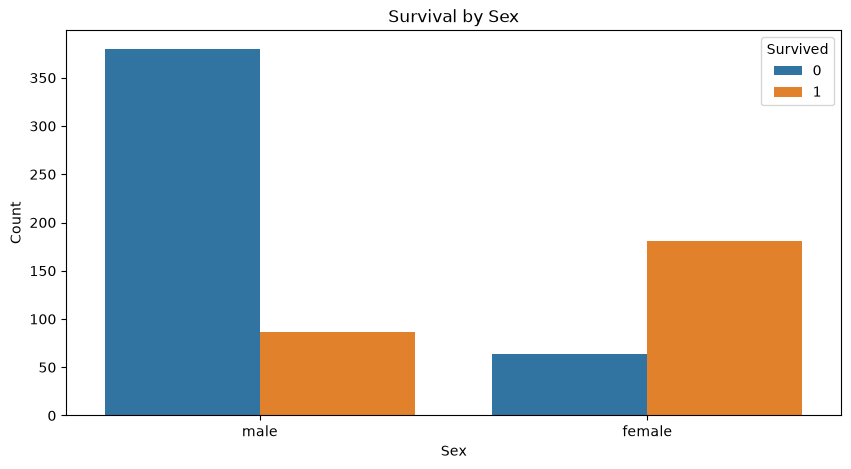

In [167]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Sex', hue='Survived')
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

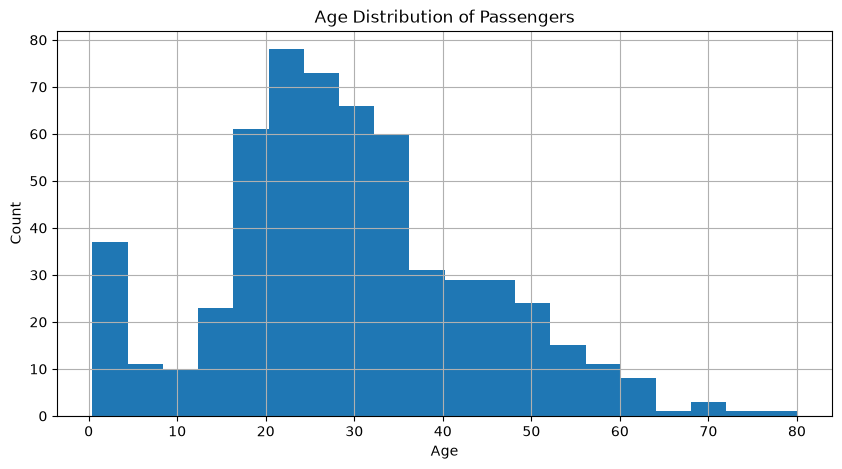

In [168]:
plt.figure(figsize=(10, 5))
train_df['Age'].hist(bins=20)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

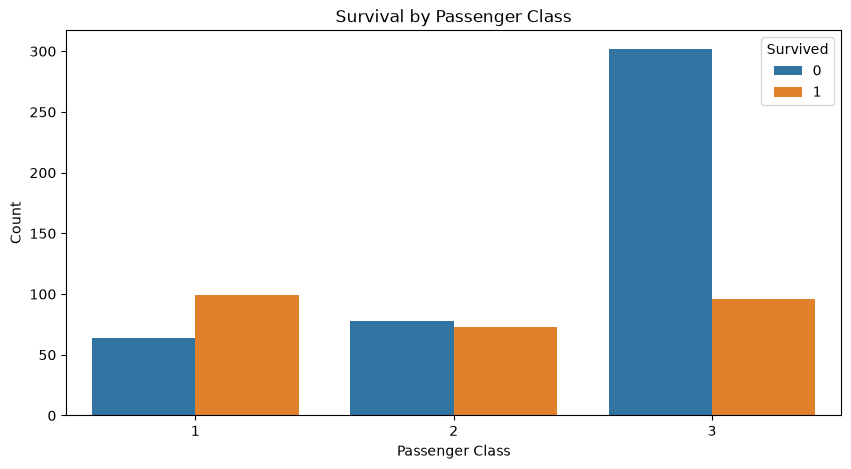

In [169]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

## Preprocess

In [170]:
def preprocess_data(df):
    if 'Age' in df.columns:
        df['Age'] = df['Age'].fillna(df['Age'].median())
    if 'Fare' in df.columns:
        df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    if 'Embarked' in df.columns:
            df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    columns_to_drop = ['Cabin', 'Ticket', 'Name']
    for column in columns_to_drop:
        if column in df.columns:
            df = df.drop(columns=[column])
    
    if 'Sex' in df.columns:
        df = pd.get_dummies(df, columns=['Sex'], drop_first=True)
    if 'Embarked' in df.columns:
        df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    
    return df

In [171]:

train_df = preprocess_data(train_df)
test_df = preprocess_data(test_df)

## Model

In [172]:
X = train_df.drop(columns=['Survived', 'PassengerId'])
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [173]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

In [174]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [ ]:
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


In [ ]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f'Best Parameters: {best_params}')
print(f'Best Cross-Validation Score: {best_score}')


In [ ]:
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)


In [ ]:

best_y_pred = best_model.predict(X_val)

# Evaluation of the best model
best_accuracy = accuracy_score(y_val, best_y_pred)
print(f'Best Validation Accuracy: {best_accuracy}')

In [ ]:
# # Validate the model
# y_pred = model.predict(X_val)
# print('Validation Accuracy:', accuracy_score(y_val, y_pred))


In [ ]:
X_test = test_df.drop(columns=['PassengerId', 'Survived'], errors='ignore')
test_predictions = grid_search.predict(X_test)

In [ ]:
test_predictions

## Create File

In [ ]:

submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

In [ ]:
submission_df

In [ ]:
submission_path = 'submission.csv'
submission_df.to_csv(submission_path, index=False)

if os.path.exists(submission_path):
    print(f"{submission_path} has been saved successfully.")
    with open(submission_path, 'r') as file:
        print(file.readlines()[:5])
else:
    print(f"Failed to save {submission_path}.")